# Měsíční KPI telekomunikační sítě: sloupce spotřeby dat s liniemi ARPU a odchodu zákazníků (PROC GBARLINE)

## Shrnutí pro vedení

Tento notebook používá **PROC GBARLINE** ke kombinaci svislého sloupcového grafu měsíční spotřeby mobilních dat s překrytými liniovými grafy ARPU, odchodu zákazníků (churn) a podpůrných tiketů — klasický dashboard KPI se "dvěma osami", který telekomunikační analytik sestavuje, aby zjistil, zda rostoucí spotřeba skutečně přechází v tržby a udržení zákazníků. Notebook generuje syntetické záznamy za jednotlivé účastníky přímo v kódu a poté využívá příkazy BAR a LINE s podskupinami, vlastními pravými osami, referenčními symboly a legendami.

## Zdroje dat

**Datová sada: `telco_kpi`** — syntetické záznamy za měsíc a účastníka (4 měsíce x 3 tarify x 8 účastníků = 96 řádků), generované přímo v kódu pomocí `call streaminit(20260531)`. Panel je udržován na 96 řádcích, aby se pohodlně vešel do limitu 100 pozorování v nelicencovaném režimu, přičemž každý měsíc a tarif zůstává plně obsazen.

| Proměnná | Typ | Popis |
|----------|------|-------------|
| `month`  | Znak | Popisek kalendářního měsíce (led–dub) |
| `plan`   | Znak | Tarif: Předplacený, Paušální, Rodinný |
| `data_gb`| Čís  | Měsíční spotřeba mobilních dat v GB (gama rozdělení, s mírným sezónním zvýšením a pomalým růstem) |
| `arpu`   | Čís  | Průměrný příjem na uživatele v USD (roste s tarifem a v průběhu měsíců) |
| `churn`  | Čís  | Měsíční příznak odchodu zákazníka (0/1, Bernoulliho rozdělení; vyšší na začátku období a u nižších tarifů) |
| `tickets`| Čís  | Otevřené podpůrné tikety (Poissonovo rozdělení) |

# Měsíční KPI telekomunikační sítě s PROC GBARLINE

Telekomunikační operátoři žijí a umírají podle hrstky měsíčních KPI: kolik **dat** účastníci spotřebují, jaké **ARPU** (průměrný příjem na uživatele) tato spotřeba generuje, kolik zákazníků **odchází** (churn) a jaká je zátěž **podpůrnými tikety** za tím vším. Tyto metriky žijí na velmi odlišných škálách — gigabajty, dolary a malé počty — takže jejich vynesení na jedinou osu odezvy skrývá příběh.

`PROC GBARLINE` je postaven přesně pro toto: kreslí svislý graf **sloupců** proti levé ose a překrývá jeden nebo více **liniových** grafů proti nezávislé pravé ose. V tomto notebooku sestavíme dashboard spotřeba-vs-tržby a poté postupně přidáváme podskupiny na úrovni tarifu, vlastní pravou osu a překryv více linií.

## Krok 1 — Generování syntetických dat za měsíc a účastníka

Následující krok DATA vytváří realistický panel: 4 měsíce (led–dub) napříč 3 tarify (Předplacený, Paušální, Rodinný) s 8 účastníky v každém, celkem 96 řádků. Generátor náhodných čísel osazujeme pomocí `call streaminit` pro reprodukovatelnost a každé KPI losujeme z rozdělení odpovídajícího dané oblasti:

- **Spotřeba dat** z gama rozdělení s mírným sezónním zvýšením a pomalým meziměsíčním růstem.
- **ARPU** rostoucí s tarifem a v průběhu měsíců, s normálním šumem.
- **Odchod zákazníků (churn)** jako Bernoulliho příznak, vyšší na začátku období a u levnějších tarifů.
- **Podpůrné tikety** jako Poissonovy počty, mírně vyšší na začátku.

Nejsou čtena žádná externí data — vše je soběstačné a panel o 96 řádcích zůstává v limitu 100 pozorování nelicencovaného režimu, takže se vykreslí každý měsíc a tarif.

In [1]:
data telco_kpi;
    CALL streaminit(20260531);
    DÉLKA month $6 plan $20;
    OPAKUJ mi = 1 TO 4;
        /* nazev mesice (primo, ne _temporary_ pole - vyhyba se
           zname chybe enginu s nediakritickymi retezci v poli) */
        KDYŽ      mi = 1 PAK month = "Led";
        JINAK KDYŽ mi = 2 PAK month = "Úno";
        JINAK KDYŽ mi = 3 PAK month = "Bře";
        JINAK                 month = "Dub";
        /* mirne sezonni zvyseni a pomaly rust dat */
        season = 1 + 0.10*sin((mi-1)/12*2*3.14159);
        OPAKUJ plan_i = 1 TO 3;
            KDYŽ plan_i = 1 PAK plan = "Předplacený";
            JINAK KDYŽ plan_i = 2 PAK plan = "Paušální";
            JINAK plan = "Rodinný";
            OPAKUJ rep = 1 TO 8;
                /* mesicni spotreba mobilnich dat (GB) */
                data_gb = rand('gamma', 4) * 3 * season
                          + (mi * 0.4);
                /* prumerny prijem na uzivatele ($) */
                arpu = 28 + 6*plan_i + rand('normal', 0, 4)
                       + mi*0.3;
                /* mesicni priznak odchodu, vyssi na zacatku roku */
                churn = rand('bernoulli',
                             0.18 - 0.03*plan_i + 0.02*(4-mi));
                /* otevrene podpurne tikety */
                tickets = rand('poisson', 1.6 + 0.15*(4-mi));
                VÝSTUP;
            KONEC;
        KONEC;
    KONEC;
    ODSTRANIT mi plan_i rep season;
SPUSTIT;


NOTE: DATA telco_kpi


NOTE: Wrote telco_kpi (96 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Krok 2 — Základní dashboard: sloupce spotřeby + linie ARPU

Toto je klasický vzor `GBARLINE`. Příkaz `BAR` vykresluje průměrnou měsíční spotřebu dat (`SUMVAR=data_gb TYPE=mean`) a jediný příkaz `LINE` překrývá průměrné ARPU na pravé ose (`STAT=mean TYPE=join`). Zapínáme ODS Graphics a dáváme grafu dvouřádkový název. `COUTLINE=` a `WIDTH=` upravují vzhled sloupců.

                                         Měsíční spotřeba mobilních dat a ARPU                                          
                                          Syntetické KPI telekomunikační sítě                                           




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: Option TITLE changed to Měsíční spotřeba mobilních dat a ARPU.
NOTE: Option TITLE2 changed to Syntetické KPI telekomunikační sítě.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


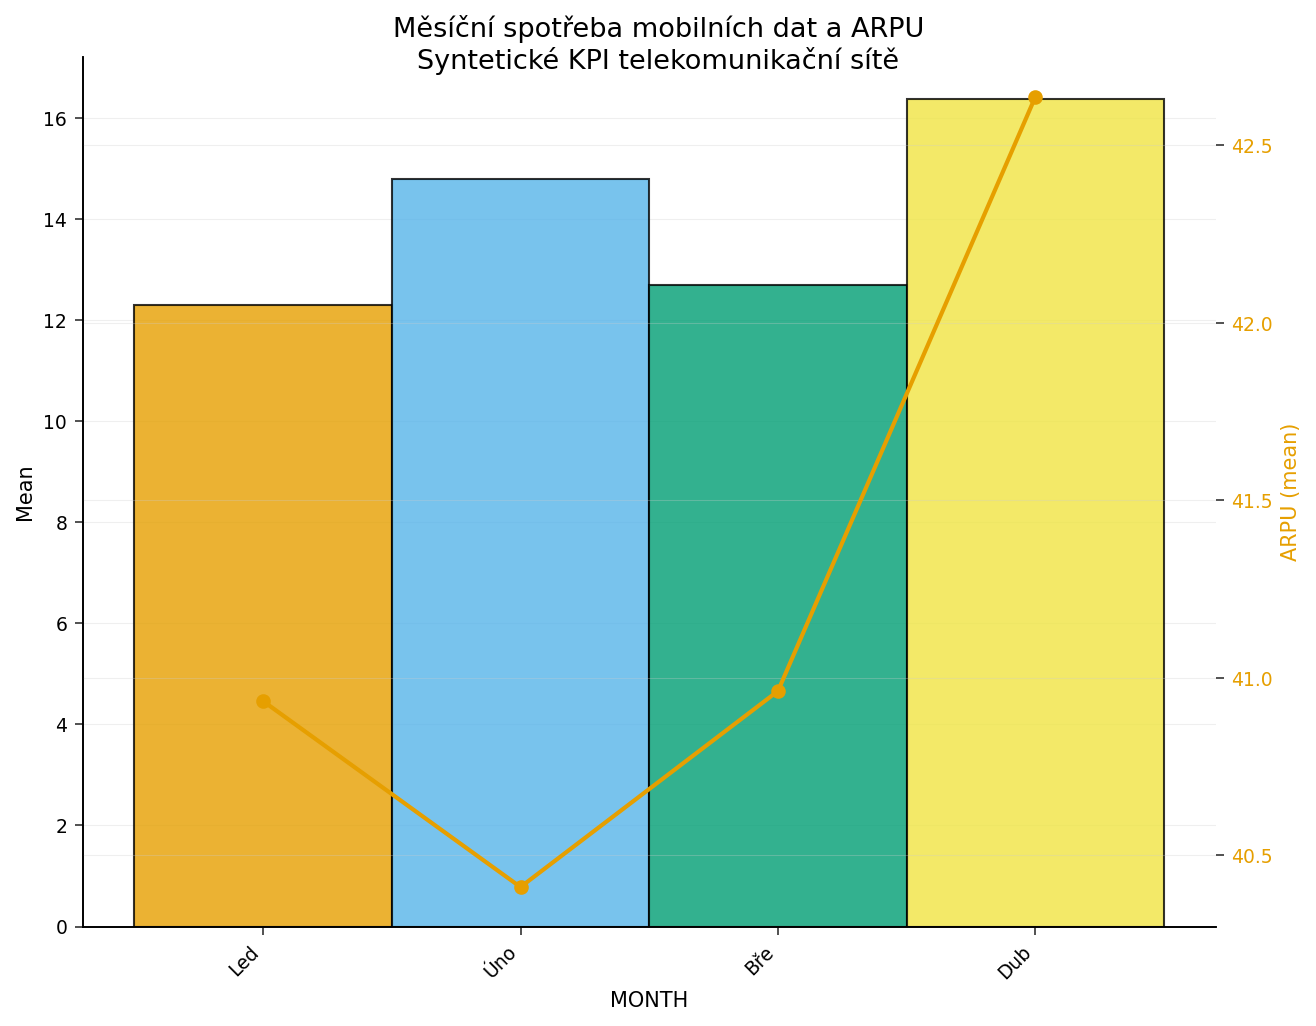

In [2]:
ODS GRAPHICS ON;
NÁZEV "Měsíční spotřeba mobilních dat a ARPU";
title2 "Syntetické KPI telekomunikační sítě";

PROCEDURA gbarline data=telco_kpi;
    bar month / SUMVAR=data_gb type=mean
                coutline=black WIDTH=6;
    line arpu / STAT=mean type=JOIN;
SPUSTIT;

## Krok 3 — Rozklad spotřeby podle tarifu, překryv odchodu zákazníků

Nahrazením `TYPE=mean` za `TYPE=sum` a přidáním `SUBGROUP=plan` se sloupec každého měsíce rozloží (skládá) podle tarifu, takže vidíme, který segment táhne celkový objem. Překrytá `LINE` nyní vykresluje měsíční **počet** událostí odchodu zákazníků jako jehlový graf (`STAT=sum TYPE=needle`) — svislé výkyvy, které se přirozeně čtou jako diskrétní počty událostí, nikoli jako hladký trend.

                                  Objem dat podle tarifu s měsíčním odchodem zákazníků                                  
                                          Syntetické KPI telekomunikační sítě                                           




NOTE: Option TITLE changed to Objem dat podle tarifu s měsíčním odchodem zákazníků.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


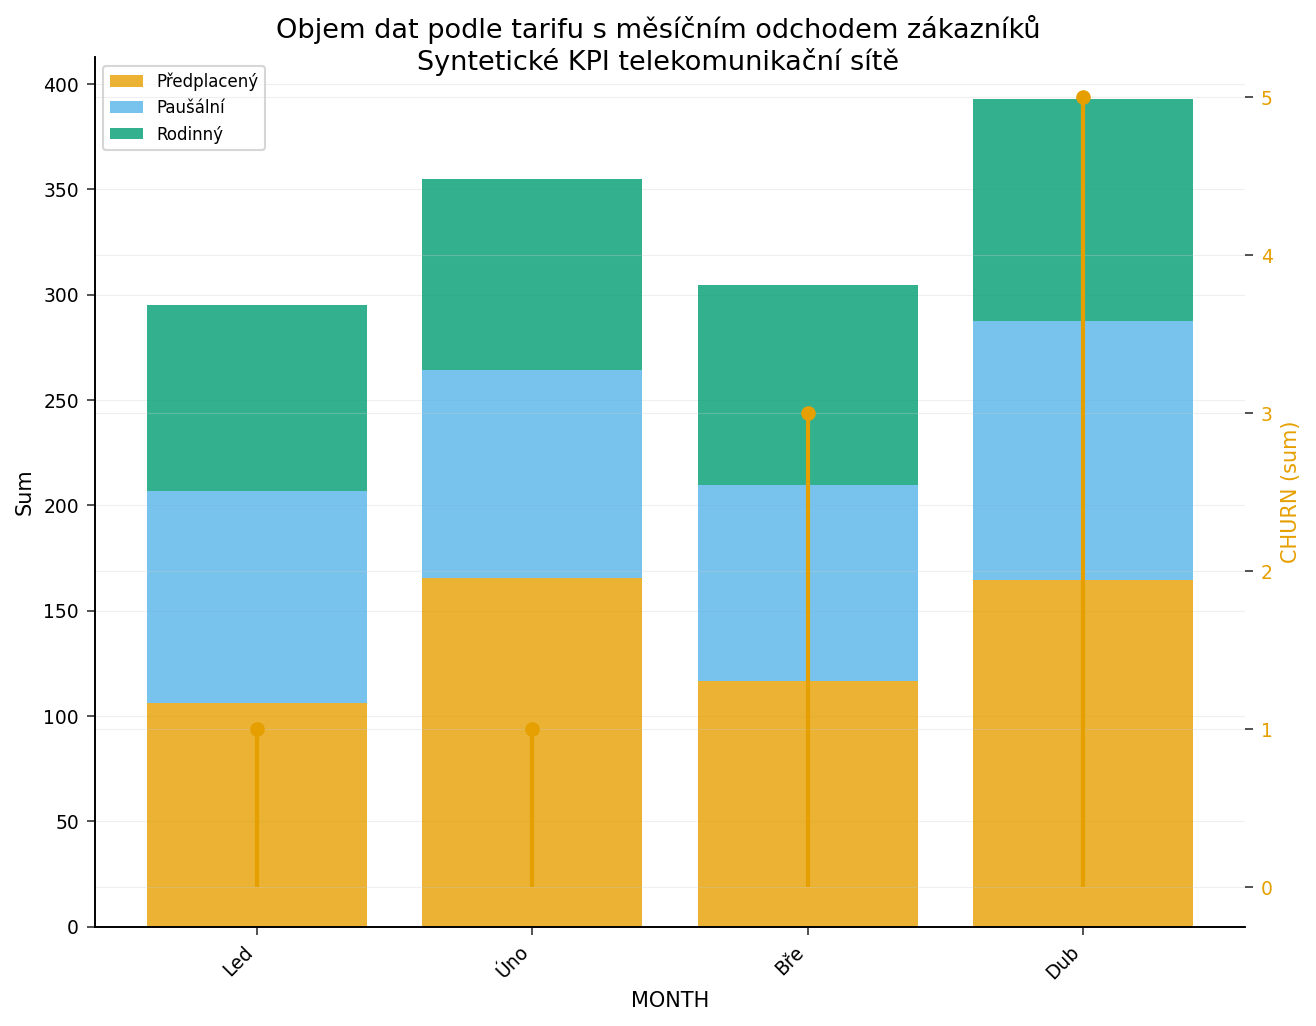

In [3]:
NÁZEV "Objem dat podle tarifu s měsíčním odchodem zákazníků";

PROCEDURA gbarline data=telco_kpi;
    bar month / SUMVAR=data_gb type=sum SUBGROUP=plan;
    line churn / STAT=sum type=needle;
SPUSTIT;

## Krok 4 — Řízení pravé osy a značky linie

Pro graf připravený k publikaci ukotvíme (pravou) osu grafu na pevný rozsah pomocí definice `AXIS` a popíšeme ji, poté ji svážeme s linií přes `RAXIS=axis2`. Definice `SYMBOL` dává linii ARPU červenou tečkovanou značku. Nad každým sloupcem také zobrazujeme celkové součty pomocí `OUTSIDE=sum`.

                                  Celková spotřeba (sloupce) vs průměrné ARPU (linie)                                   
                                          Syntetické KPI telekomunikační sítě                                           




NOTE: Option TITLE changed to Celková spotřeba (sloupce) vs průměrné ARPU (linie).
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


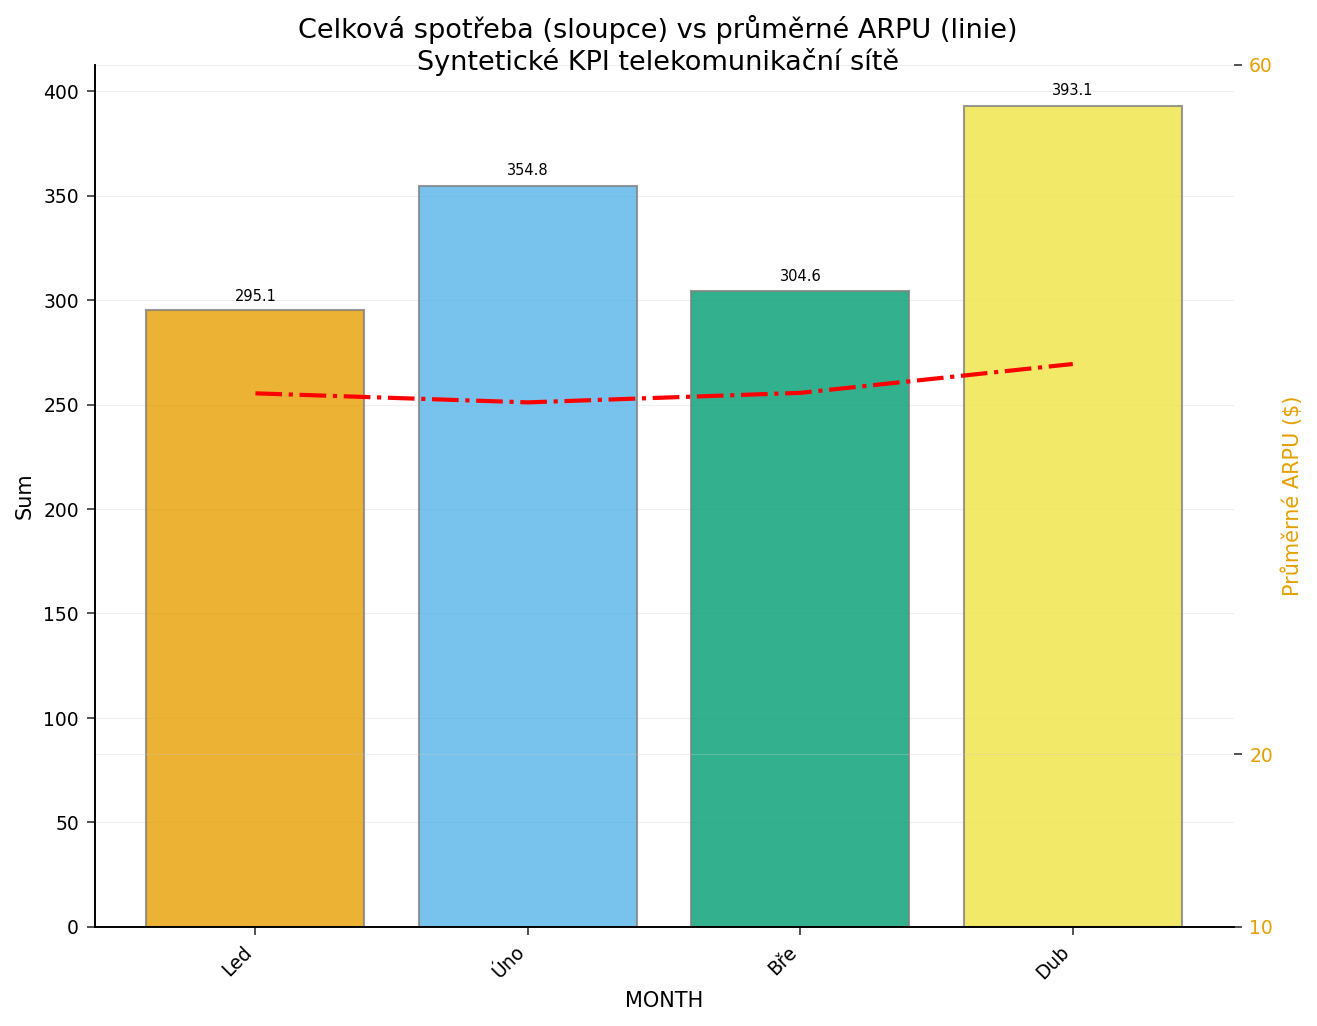

In [4]:
NÁZEV "Celková spotřeba (sloupce) vs průměrné ARPU (linie)";

PROCEDURA gbarline data=telco_kpi;
    axis2 ORDER=(20 TO 60 PODLE 10) ŠTÍTEK=("Průměrné ARPU ($)");
    symbol1 color=red INTERPOL=JOIN VALUE=dot HEIGHT=1.4;
    bar month / SUMVAR=data_gb type=sum
                outside=sum coutline=gray;
    line arpu / STAT=mean type=JOIN raxis=axis2 SYMBOL=symbol1;
SPUSTIT;

## Krok 5 — Více překrytých linií s vlastní legendou

`GBARLINE` přijímá více než jeden příkaz `LINE`, takže můžeme proti sloupcům spotřeby porovnat dva provozní signály najednou: průměrné podpůrné tikety (`type=join`) a celkový odchod zákazníků (`type=needle`). Definice `LEGEND` umístěná dole dokumentuje podskupiny tarifů.

                                      Trendy podpůrných tiketů a odchodu zákazníků                                      
                                          Syntetické KPI telekomunikační sítě                                           




NOTE: Option TITLE changed to Trendy podpůrných tiketů a odchodu zákazníků.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json
NOTE: ODS Graphics is OFF.


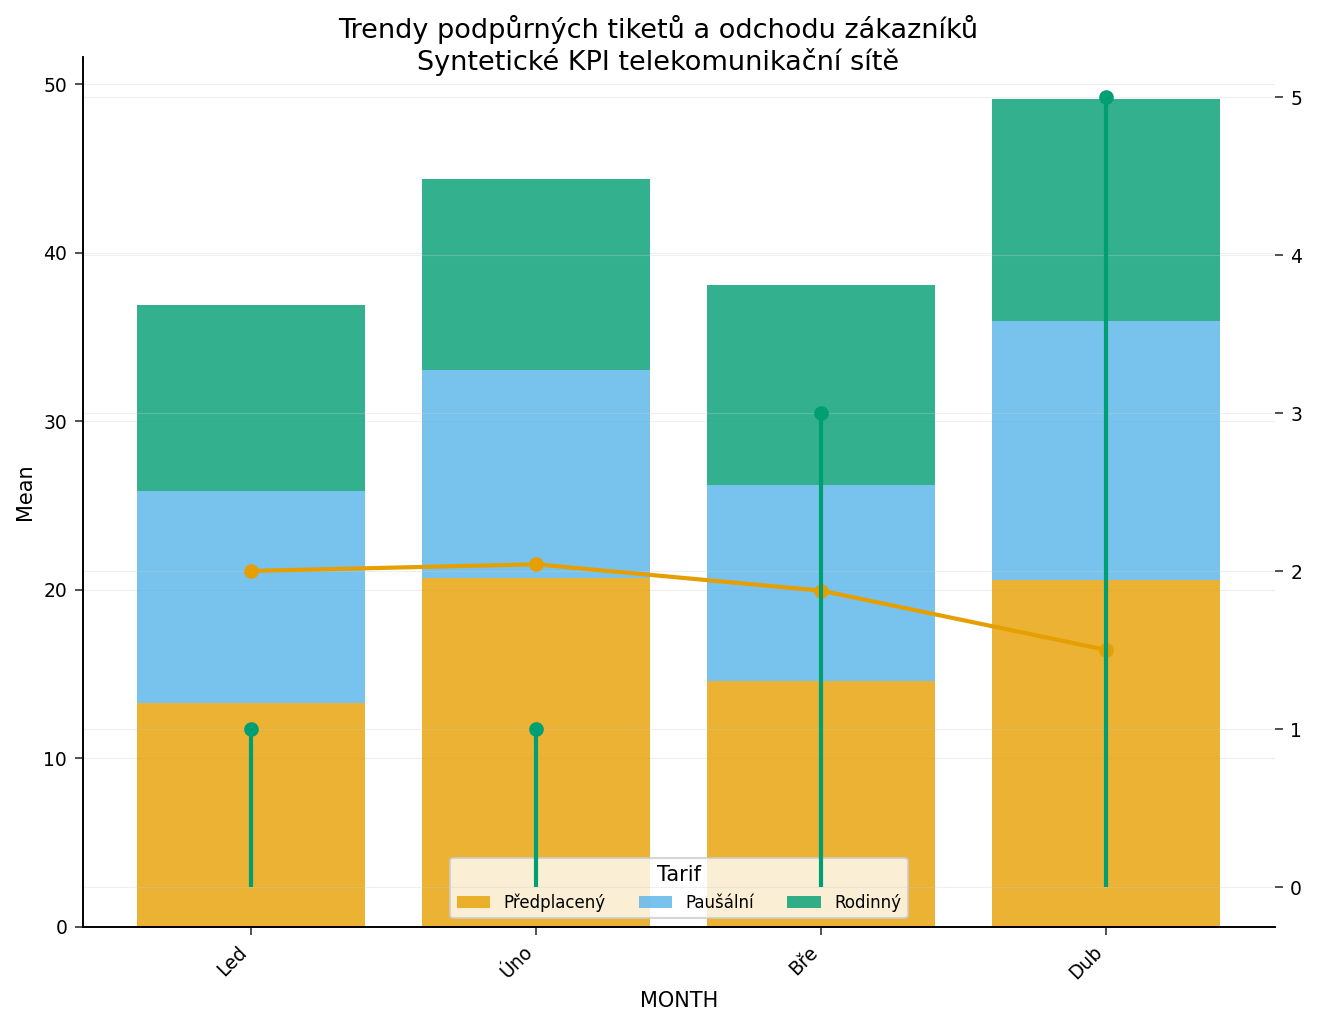

In [5]:
NÁZEV "Trendy podpůrných tiketů a odchodu zákazníků";

PROCEDURA gbarline data=telco_kpi;
    legend1 ŠTÍTEK=("Tarif") position=(bottom) ACROSS=3;
    bar month / SUMVAR=data_gb type=mean SUBGROUP=plan
                legend=legend1;
    line tickets / STAT=mean type=JOIN;
    line churn / STAT=sum type=needle;
SPUSTIT;

ODS GRAPHICS OFF;

## Interpretace výsledků

Napříč obdobím led–dub vypráví dashboard souvislý telekomunikační příběh. **Spotřeba dat** (sloupce) je meziměsíčně kolísavá, ale trend je rostoucí, s vrcholem v **dubnu** — průměrná spotřeba stoupá z asi 12,3 GB v lednu na 16,4 GB v dubnu (Krok 2) a celkový objem z 295 GB na 393 GB (popisky `OUTSIDE=sum` v Kroku 4). **Linie ARPU** mírně klesá v únoru a poté stoupá na své vlastní dubnové maximum blízko 42,6 USD, takže operátor stále více zpeněžuje dodatečnou spotřebu, místo aby ji poskytoval zdarma — pravá osa v Kroku 4 je ukotvena na 20–60 USD, aby byl tento pohyb čitelný.

Pohledy rozložené podle tarifu (Kroky 3 a 5) odhalují segmentové napětí typické pro operátory s vysokým podílem předplacených tarifů. **Předplacený** tarif (oranžové pásmo) nese celkově nejvíce gigabajtů — zhruba 553 GB za čtyři měsíce oproti 415 GB u Paušálního a 380 GB u Rodinného — přesto vydělává **nejnižší** průměrný příjem na uživatele (asi 36 USD, oproti 41 USD u Paušálního a 47 USD u Rodinného). **Jehly odchodu zákazníků** potvrzují, kde leží riziko udržení: události odchodu se soustřeďují u Předplaceného a Paušálního tarifu (4 události u každého za dané období) a zůstávají mírnější u Rodinného (2), přičemž směrem k dubnu rostou s tím, jak se rozšiřuje základna účastníků a spotřeba.

Krok 5 na to navrstvuje provozní zátěž: průměrné **podpůrné tikety** jsou o něco vyšší na začátku období a k dubnu klesají, zatímco jehly odchodu zákazníků vrcholí později — signál, který tým pro udržení zákazníků sleduje. Provozně to ukazuje na soustředění výdajů na udržení na účastníky s **Předplaceným** tarifem, kteří spotřebovávají nejrychleji rostoucí podíl objemu dat, přičemž generují nejméně tržeb a nejvíce odchodů.

`PROC GBARLINE` je zde tím správným nástrojem přesně proto, že udržuje sloupce v měřítku gigabajtů a linie v měřítku dolarů/počtů na nezávislých osách, což umožňuje číst každé KPI na jeho vlastních podmínkách při současném sdílení měsíční časové osy.